<a href="https://colab.research.google.com/github/habeebshahida330-lab/AIML-DS_Project_2/blob/main/Minor_Project_2_Linear_Regression_Salary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/SalaryPrediction.csv')

In [ ]:
df.head()

,Experience Years,Salary
0,1.1,39343
1,1.2,42774
2,1.3,46205
3,1.5,37731
4,2.0,43525


In [ ]:
print("Shape of dataset:", df.shape)

print("\nColumns in dataset:")
print(df.columns)

Shape of dataset: (40, 2)

Columns in dataset:
Index(['Experience Years', 'Salary'], dtype='object')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Experience Years  40 non-null     float64
 1   Salary            40 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 772.0 bytes


In [ ]:
df.isnull().sum()

,0
Experience Years,0
Salary,0


In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [ ]:
df.describe()

,Experience Years,Salary
count,40.000000,40.000000
mean,5.152500,74743.625000
std,2.663715,25947.122885
min,1.100000,37731.000000
25%,3.200000,56878.250000
50%,4.600000,64472.500000
75%,6.875000,95023.250000
max,10.500000,122391.000000


In [ ]:
print(df.dtypes)

Experience Years    float64
Salary                int64
dtype: object


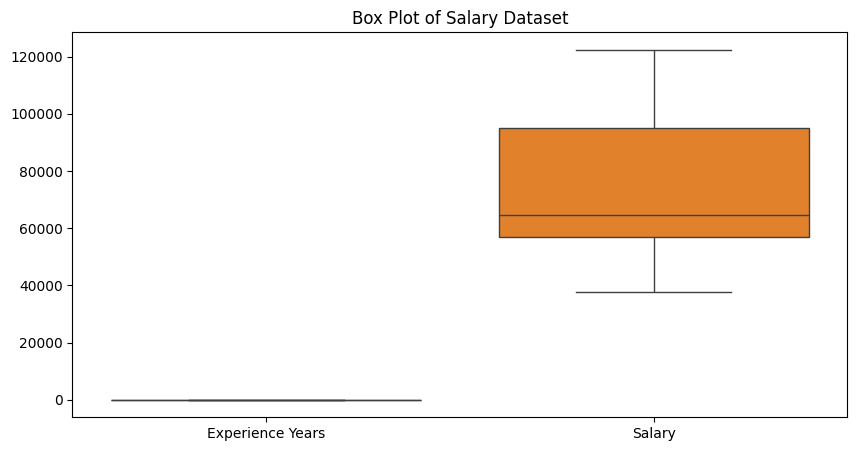

In [ ]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=df)

plt.title("Box Plot of Salary Dataset")
plt.show()

In [ ]:
correlation = df.corr(numeric_only=True)

print(correlation)

                  Experience Years    Salary
Experience Years          1.000000  0.977692
Salary                    0.977692  1.000000


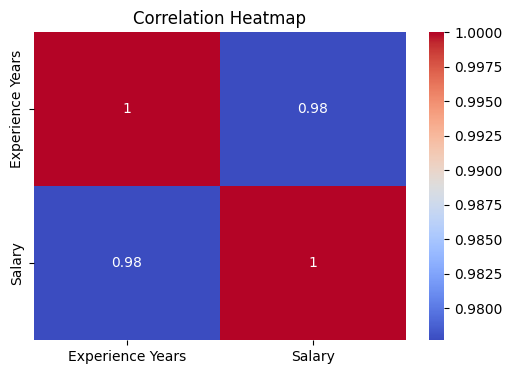

In [ ]:
plt.figure(figsize=(6, 4))

sns.heatmap(correlation, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

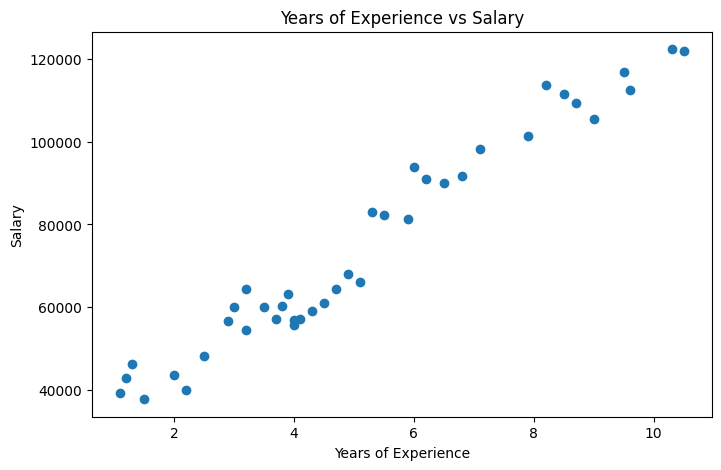

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Experience Years"], df["Salary"])

plt.title("Years of Experience vs Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")

plt.show()

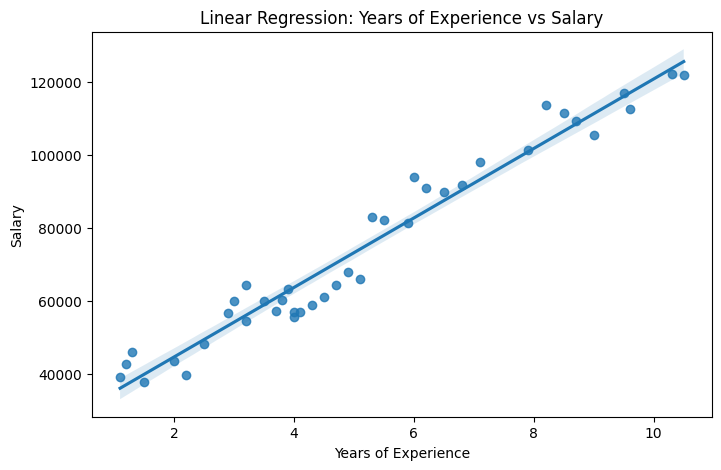

In [ ]:
plt.figure(figsize=(8, 5))

sns.regplot(
    x=df["Experience Years"],
    y=df["Salary"]
)

plt.title("Linear Regression: Years of Experience vs Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")

plt.show()

In [ ]:
X = df[["Experience Years"]]
y = df["Salary"]

In [ ]:
print("X:")
print(X.head())

print("\ny:")
print(y.head())

X:
   Experience Years
0               1.1
1               1.2
2               1.3
3               1.5
4               2.0

y:
0    39343
1    42774
2    46205
3    37731
4    43525
Name: Salary, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (32, 1)
X_test: (8, 1)
y_train: (32,)
y_test: (8,)


In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
print("Intercept:", model.intercept_)

Intercept: 26716.250176145535


In [ ]:
print("Coefficient:", model.coef_[0])

Coefficient: 9408.03127250658


In [ ]:
y_pred = model.predict(X_test)

print(y_pred)

[ 69052.39090243  64348.37526617  64348.37526617  83164.43781119
  45532.31272116  61525.96588442 117033.35039221  85046.04406569]


In [ ]:
comparison = pd.DataFrame({
    "Actual Salary": y_test.values,
    "Predicted Salary": y_pred
})

comparison

,Actual Salary,Predicted Salary
0,61111,69052.390902
1,56957,64348.375266
2,55794,64348.375266
3,93940,83164.437811
4,43525,45532.312721
5,57189,61525.965884
6,112635,117033.350392
7,91000,85046.044066


In [ ]:
from sklearn import metrics
mae = metrics.mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 6419.911069460598


In [ ]:
mse = metrics.mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 48077731.16919359


In [ ]:
rmse = np.sqrt(mse)

print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 6933.810724932834


In [ ]:
r2 = metrics.r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.9068577573647874


In [ ]:
print("Model Evaluation")
print("------------------------")
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R²   :", r2)

Model Evaluation
------------------------
MAE  : 6419.911069460598
MSE  : 48077731.16919359
RMSE : 6933.810724932834
R²   : 0.9068577573647874


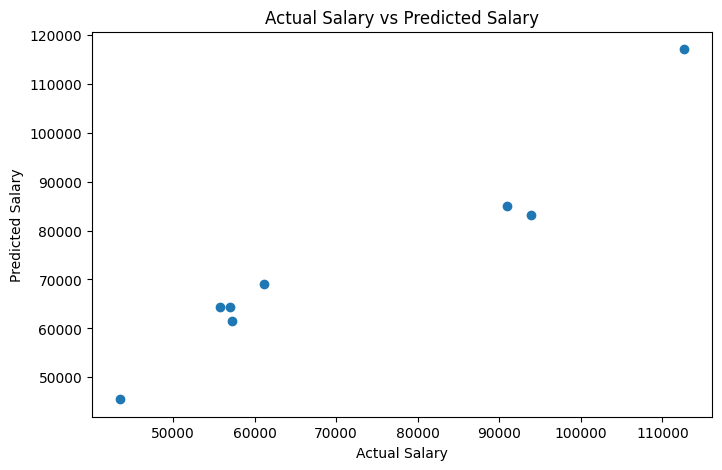

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual Salary vs Predicted Salary")

plt.show()

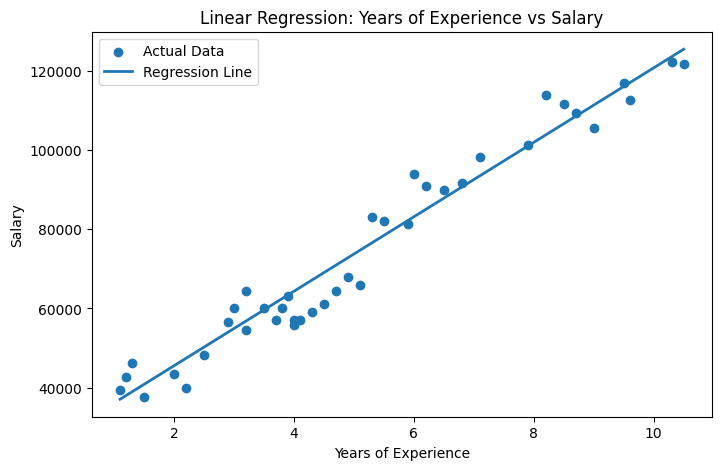

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(X, y, label="Actual Data")

plt.plot(
    X,
    model.predict(X),
    linewidth=2,
    label="Regression Line"
)

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Linear Regression: Years of Experience vs Salary")

plt.legend()
plt.show()

In [ ]:
new_experience = [[5]]

predicted_salary = model.predict(new_experience)

print("Predicted salary for 5 years of experience:",
      predicted_salary[0])

Predicted salary for 5 years of experience: 73756.40653867844


In [ ]:
new_experience = [[10]]

predicted_salary = model.predict(new_experience)

print("Predicted salary for 10 years of experience:",
      predicted_salary[0])

Predicted salary for 10 years of experience: 120796.56290121133


In [ ]:
error = y_test - y_pred

print(error)

19    -7941.390902
16    -7391.375266
15    -8554.375266
26    10775.562189
4     -2007.312721
12    -4336.965884
37    -4398.350392
27     5953.955934
Name: Salary, dtype: float64


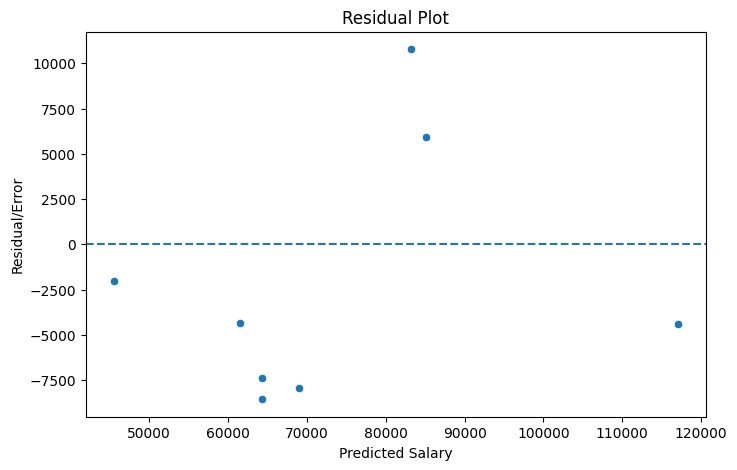

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(x=y_pred, y=error)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Salary")
plt.ylabel("Residual/Error")
plt.title("Residual Plot")

plt.show()

In [ ]:
print("Correlation between YearsExperience and Salary:")
print(df["Experience Years"].corr(df["Salary"]))

Correlation between YearsExperience and Salary:
0.9776918968570496


MINOR PROJECT 2
Linear Regression – Salary Prediction

1. Import Libraries

2. Load Dataset

3. Dataset Overview
   - head()
   - shape
   - columns
   - info()

4. Data Cleaning
   - missing values
   - duplicates
   - data types

5. Exploratory Data Analysis
   - describe()
   - box plot
   - correlation
   - heatmap

6. Data Visualization
   - scatter plot
   - regression plot

7. Independent and Dependent Variables
   - X = YearsExperience
   - y = Salary

8. Train-Test Split

9. Linear Regression Model

10. Model Training

11. Intercept and Coefficient

12. Prediction

13. Actual vs Predicted

14. Model Evaluation
   - MAE
   - MSE
   - RMSE
   - R²

15. Regression Line

16. New Salary Prediction

17. Residual Analysis

18. Key Findings

19. Conclusion